# Universidad del Valle de Guatemala  
## Departamento de Ciencias de la Computación  
## Data Science - sección 40

### Cristian Túnchez (231359)  
### Nadissa López (23764)

# Laboratorio 5: clasificación de tweets sobre desastres

## 1. Descripción del laboratorio

El objetivo es estudiar tweets en inglés y construir una línea base que prediga si describen un desastre real (`target = 1`) o si usan vocabulario relacionado con desastres en otro contexto (`target = 0`). El laboratorio cubre descripción, preprocesamiento, n-gramas, clasificación supervisada, análisis de sentimientos y evaluación del aporte de una variable de negatividad. La selección final se realiza sin utilizar el conjunto de prueba.

El procesamiento realizado es consistente con lo aprendido en clase: 
**texto crudo → texto limpio → números → modelo → conocimiento**. 

Las reglas lingüísticas se muestran antes del modelado para poder explicar qué información se conserva y cuál se descarta.

In [1]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from sklearn.metrics import ConfusionMatrixDisplay
from wordcloud import WordCloud

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 120)
sns.set_theme(style="whitegrid", palette="colorblind")

SEED = 42
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.exploration import (
    dataset_summary,
    plot_length_analysis,
    plot_missing_values,
    plot_target_distribution,
    top_keywords,
)
from src.model import build_pipeline, coefficient_terms, evaluate_model, split_data
from src.ngrams import compare_classes, top_by_class
from src.preprocessing import (
    build_processed_dataset,
    english_stopwords,
    find_train_csv,
    normalize_tweet,
    preprocess_tweet,
    save_processed_dataset,
    tokenize_tweet,
)

## 2. Carga de datos

`train.csv` es la fuente de verdad y se lee sin modificar. La función de carga admite que el archivo esté directamente en `data/raw/` o dentro de la carpeta creada al descomprimir la descarga oficial de Kaggle.

In [2]:
TRAIN_PATH = find_train_csv(ROOT)
PROCESSED_PATH = ROOT / "data" / "processed" / "train_processed.csv"

df_raw = pd.read_csv(TRAIN_PATH)
print(f"Archivo: {TRAIN_PATH.relative_to(ROOT)}")
print(f"Dimensiones: {df_raw.shape[0]:,} filas × {df_raw.shape[1]} columnas")
display(df_raw.head())

Archivo: data\raw\nlp-getting-started\train.csv
Dimensiones: 7,613 filas × 5 columnas


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are being notified by officers. No other evacuation or shelter in place or...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation orders in California",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as smoke from #wildfires pours into a school,1


## 3. Descripción del dataset

Primero comprobamos dimensiones, nombres y tipos. También se distinguen filas duplicadas de textos repetidos: dos registros podrían compartir texto sin ser idénticos en todas sus columnas.

In [3]:
summary = dataset_summary(df_raw)

schema_table = pd.DataFrame({
    "dtype": summary["dtypes"],
    "missing": summary["missing"],
    "missing_pct": summary["missing"] / len(df_raw),
})
display(schema_table.style.format({"missing_pct": "{:.2%}"}))

print(f"Filas duplicadas completas: {summary['duplicate_rows']:,}")
print(f"Textos duplicados: {summary['duplicate_texts']:,}")
display(summary["target_counts"].rename("frequency").to_frame().join(
    summary["target_proportions"].rename("proportion")
).style.format({"proportion": "{:.2%}"}))

,dtype,missing,missing_pct
id,int64,0,0.00%
keyword,str,61,0.80%
location,str,2533,33.27%
text,str,0,0.00%
target,int64,0,0.00%


Filas duplicadas completas: 0
Textos duplicados: 110


,frequency,proportion
target,,
0,4342,57.03%
1,3271,42.97%


## 4. Análisis exploratorio inicial

Los siguientes gráficos responden preguntas concretas: (1) ¿hay desbalance entre clases?, (2) ¿en qué columnas se concentran los faltantes?, y (3) ¿la longitud del texto cambia entre tweets de desastre y no desastre?

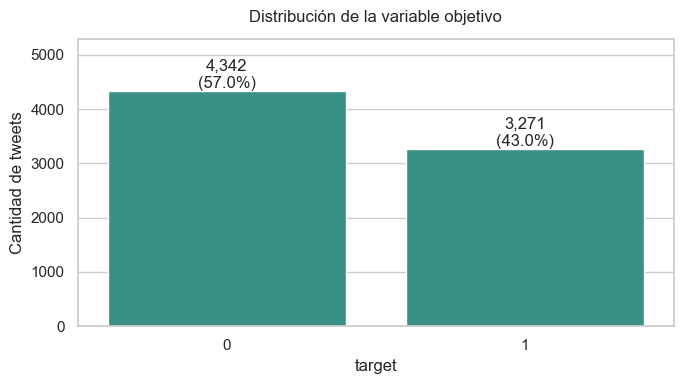

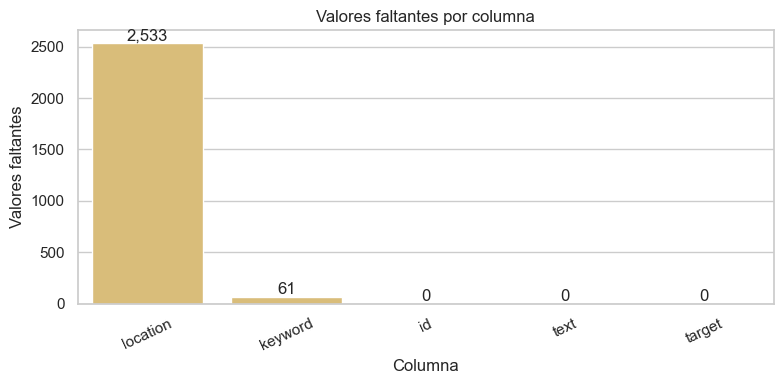

In [4]:
plot_target_distribution(df_raw)
plt.show()

plot_missing_values(df_raw)
plt.show()

n_chars                                                 n_words_raw  \
         count    mean    std   min   25%    50%    75%    max       count   
target                                                                       
0       4342.0   95.71  35.89   7.0  68.0  101.0  130.0  157.0      4342.0   
1       3271.0  108.11  29.31  14.0  88.0  115.0  136.0  151.0      3271.0   

                                                  
         mean   std  min   25%   50%   75%   max  
target                                            
0       14.70  6.16  1.0  10.0  15.0  19.0  31.0  
1       15.17  5.10  2.0  11.0  15.0  19.0  30.0

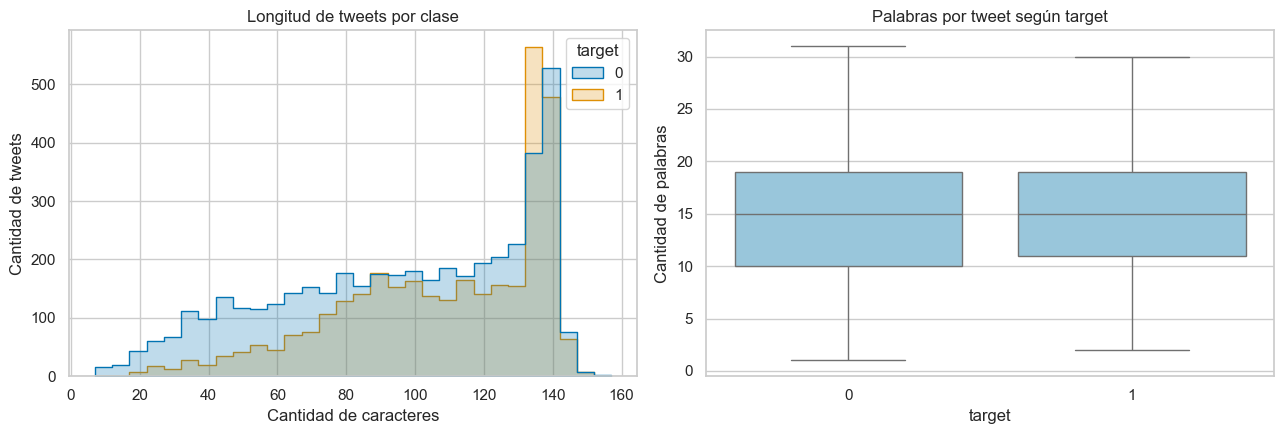

In [5]:
lengths_raw = df_raw.assign(
    n_chars=df_raw["text"].fillna("").str.len(),
    n_words_raw=df_raw["text"].fillna("").str.split().str.len(),
)
display(lengths_raw.groupby("target")[["n_chars", "n_words_raw"]].describe().round(2))
plot_length_analysis(lengths_raw)
plt.show()

Keywords faltantes: 61 (0.80%)
Locations faltantes: 2,533 (33.27%)


,keyword,frequency
0,fatalities,45
1,armageddon,42
2,deluge,42
3,body bags,41
4,damage,41
5,harm,41
6,sinking,41
7,collided,40
8,evacuate,40
9,fear,40


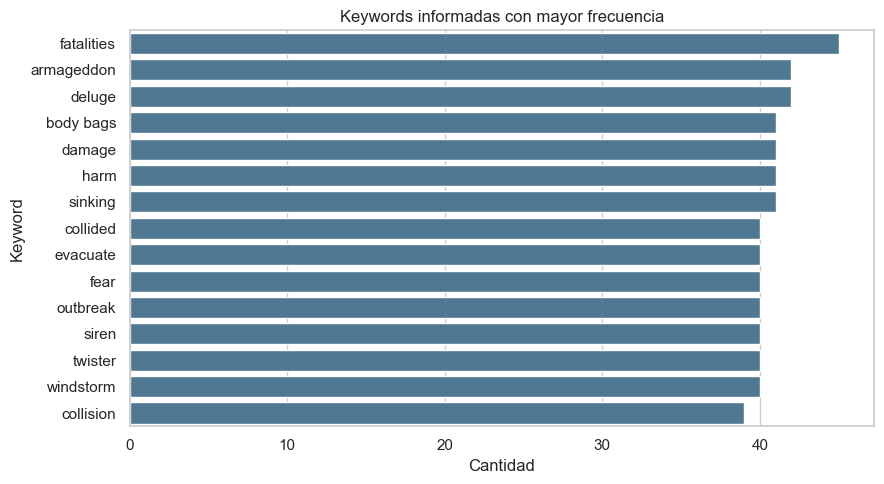

In [6]:
print(f"Keywords faltantes: {df_raw['keyword'].isna().sum():,} ({df_raw['keyword'].isna().mean():.2%})")
print(f"Locations faltantes: {df_raw['location'].isna().sum():,} ({df_raw['location'].isna().mean():.2%})")

keywords_top = top_keywords(df_raw, n=15)
display(keywords_top)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=keywords_top, y="keyword", x="frequency", ax=ax, color="#457b9d")
ax.set(title="Keywords informadas con mayor frecuencia", xlabel="Cantidad", ylabel="Keyword")
plt.tight_layout()
plt.show()

In [7]:
examples = pd.concat([
    df_raw[df_raw["target"] == 0].sample(3, random_state=SEED),
    df_raw[df_raw["target"] == 1].sample(3, random_state=SEED),
]).sort_values("target")
display(examples[["id", "keyword", "location", "text", "target"]])

,id,keyword,location,text,target
3697,5260,fatality,NaN,Everyday is a near death fatality for me on the road. Thank god is on my side.??,0
4180,5937,hazard,Australia,#Lifestyle Û÷It makes me sickÛª: Baby clothes deemed a Û÷hazardÛª http://t.co/0XrfVidxA2 http://t.co/oIHwgEZDCk,0
4634,6586,inundated,"England & Wales Border, UK",@Lenn_Len Probably. We are inundated with them most years!,0
4008,5692,floods,North America,Nearly 50 thousand people affected by floods in #Paraguay ? http://t.co/aw23wXtyjB http://t.co/ABgct9VFUa,1
325,471,armageddon,"Florida, USA",Vladimir Putin Issues Major Warning But Is It Too Late To Escape Armageddon?\nhttp://t.co/gBxafy1m1C,1
1215,1753,buildings%20burning,somewhere over a rainbow,@DoctorFluxx @StefanEJones @spinnellii @themermacorn No burning buildings and rob during a riot. That's embarrassin...,1


## 5. Preprocesamiento

Las decisiones se tomaron para reducir ruido sin borrar señales propias de Twitter:

- **Minúsculas:** unifica `Fire`, `FIRE` y `fire`. Se pierde el énfasis de las mayúsculas, pero se evita fragmentar el vocabulario.
- **URLs:** se reemplazan por `token_url`. El destino exacto suele ser único y ruidoso; el hecho de incluir un enlace puede conservar señal.
- **Menciones:** se reemplazan por `token_user`. Se evita aprender nombres de cuentas concretas y se conserva la presencia de una interacción.
- **Hashtags:** se elimina `#`, pero permanece la palabra. Un hashtag puede resumir el evento (`#earthquake`) y eliminarlo completo perdería información temática.
- **Puntuación y caracteres especiales:** se eliminan como separadores. El apóstrofe se conserva dentro de contracciones para distinguir `don't` de `don`.
- **Emojis:** se transforman a tokens Unicode, por ejemplo `emoji_u1f525`. No se interpretan como sentimiento en esta entrega, pero tampoco se destruye una señal útil para la segunda etapa.
- **Números:** se conservan. Cantidades, fechas y términos como `911` pueden estar relacionados con emergencias.
- **Stopwords:** se usa la lista inglesa de NLTK porque el corpus está en inglés. Se conservan negaciones (`no`, `not`, `never`, `don't`, etc.) para no invertir el significado.
- **Tokenización:** una expresión regular separa palabras, contracciones, números y marcadores especiales. Es más controlada que un simple corte por espacios.

### Stemming frente a lematización

El **stemming** recorta terminaciones con reglas rápidas y puede producir raíces que no son palabras; la **lematización** busca una forma de diccionario y suele necesitar más información lingüística. En esta línea base no se usa ninguna. El stemming dificultaría interpretar los coeficientes, y la lematización añade costo y dependencias para una colección corta en inglés. TF-IDF, `min_df` y la eliminación razonada de stopwords ya controlan parte del vocabulario. Esta decisión no impide reevaluar la lematización en la segunda entrega.

In [8]:
demo_texts = [
    "@news BREAKING: Forest fire near Route 911! https://t.co/example #Wildfire 🔥",
    "I don't think this movie was a disaster 😂",
]
stop_words = english_stopwords()

for text in demo_texts:
    print("ORIGINAL:  ", text)
    print("NORMALIZADO:", normalize_tweet(text))
    print("TOKENS:     ", tokenize_tweet(text))
    print("PROCESADO:  ", preprocess_tweet(text, stop_words), "\n")

ORIGINAL:   @news BREAKING: Forest fire near Route 911! https://t.co/example #Wildfire 🔥
NORMALIZADO: token_user breaking forest fire near route 911 token_url wildfire emoji_u1f525
TOKENS:      ['token_user', 'breaking', 'forest', 'fire', 'near', 'route', '911', 'token_url', 'wildfire', 'emoji_u1f525']
PROCESADO:   token_user breaking forest fire near route 911 token_url wildfire emoji_u1f525 

ORIGINAL:   I don't think this movie was a disaster 😂
NORMALIZADO: i don't think this movie was a disaster emoji_u1f602
TOKENS:      ['i', "don't", 'think', 'this', 'movie', 'was', 'a', 'disaster', 'emoji_u1f602']
PROCESADO:   don't think movie disaster emoji_u1f602 



## 6. Verificación del texto procesado

El dataset procesado se genera por código y se guarda fuera de `data/raw/`. Revisamos pares antes/después y verificamos que la transformación no produzca textos vacíos de manera inesperada.

In [9]:
df = build_processed_dataset(df_raw)
save_processed_dataset(df, PROCESSED_PATH)

print(f"Archivo generado: {PROCESSED_PATH.relative_to(ROOT)}")
print(f"Textos procesados vacíos: {df['text_processed'].eq('').sum():,}")
display(df[["text", "text_processed", "target"]].sample(10, random_state=SEED))

Archivo generado: data\processed\train_processed.csv
Textos procesados vacíos: 0


,text,text_processed,target
2644,So you have a new weapon that can cause un-imaginable destruction.,new weapon cause un imaginable destruction,1
2227,The f$&amp;@ing things I do for #GISHWHES Just got soaked in a deluge going for pads and tampons. Thx @mishacollins @/@,token_user things gishwhes got soaked deluge going pads tampons thx token_user,0
5448,DT @georgegalloway: RT @Galloway4Mayor: ÛÏThe CoL police can catch a pickpocket in Liverpool Stree... http://t.co/v...,dt token_user rt token_user col police catch pickpocket liverpool stree token_url,1
132,Aftershock back to school kick off was great. I want to thank everyone for making it possible. What a great night.,aftershock back school kick great want thank everyone making possible great night,0
6845,in response to trauma Children of Addicts develop a defensive self - one that decreases vulnerability. (3,response trauma children addicts develop defensive self one decreases vulnerability 3,0
5559,@Calum5SOS you look like you got caught in a rainstorm this is amazing and disgusting at the same time,token_user look like got caught rainstorm amazing disgusting time,0
1765,my favorite lady came to our volunteer meeting\nhopefully joining her youth collision and i am excite http://t.co/Ij...,favorite lady came volunteer meeting hopefully joining youth collision excite token_url,1
1817,@brianroemmele UX fail of EMV - people want to insert and remove quickly like a gas pump stripe reader. 1 person tol...,token_user ux fail emv people want insert remove quickly like gas pump stripe reader 1 person told crashed pos,1
6810,Can't find my ariana grande shirt this is a fucking tragedy,can't find ariana grande shirt fucking tragedy,0
4398,The Murderous Story Of AmericaÛªs First Hijacking http://t.co/EYUGk6byxr,murderous story america first hijacking token_url,1


## 7. Unigramas

Un unigrama es un token aislado. La frecuencia absoluta cuenta apariciones. La probabilidad mostrada es:

\[
P(w \mid c) = \frac{\text{apariciones de } w \text{ en la clase } c}{\text{total de unigramas en la clase } c}
\]

No es la probabilidad de que un tweet pertenezca a una clase; indica qué proporción de los tokens de esa clase corresponde a la palabra.

Unigramas más frecuentes en target = 0


,ngram,frequency,probability
0,token_url,2204,5.3446%
1,token_user,1823,4.4207%
2,like,254,0.6159%
3,not,205,0.4971%
4,new,171,0.4147%
5,get,163,0.3953%
6,no,151,0.3662%
7,one,131,0.3177%
8,don't,126,0.3055%
9,body,115,0.2789%


Unigramas más frecuentes en target = 1


,ngram,frequency,probability
0,token_url,2519,7.0996%
1,token_user,889,2.5056%
2,fire,182,0.5130%
3,news,139,0.3918%
4,disaster,121,0.3410%
5,via,121,0.3410%
6,no,115,0.3241%
7,suicide,112,0.3157%
8,california,111,0.3128%
9,police,109,0.3072%


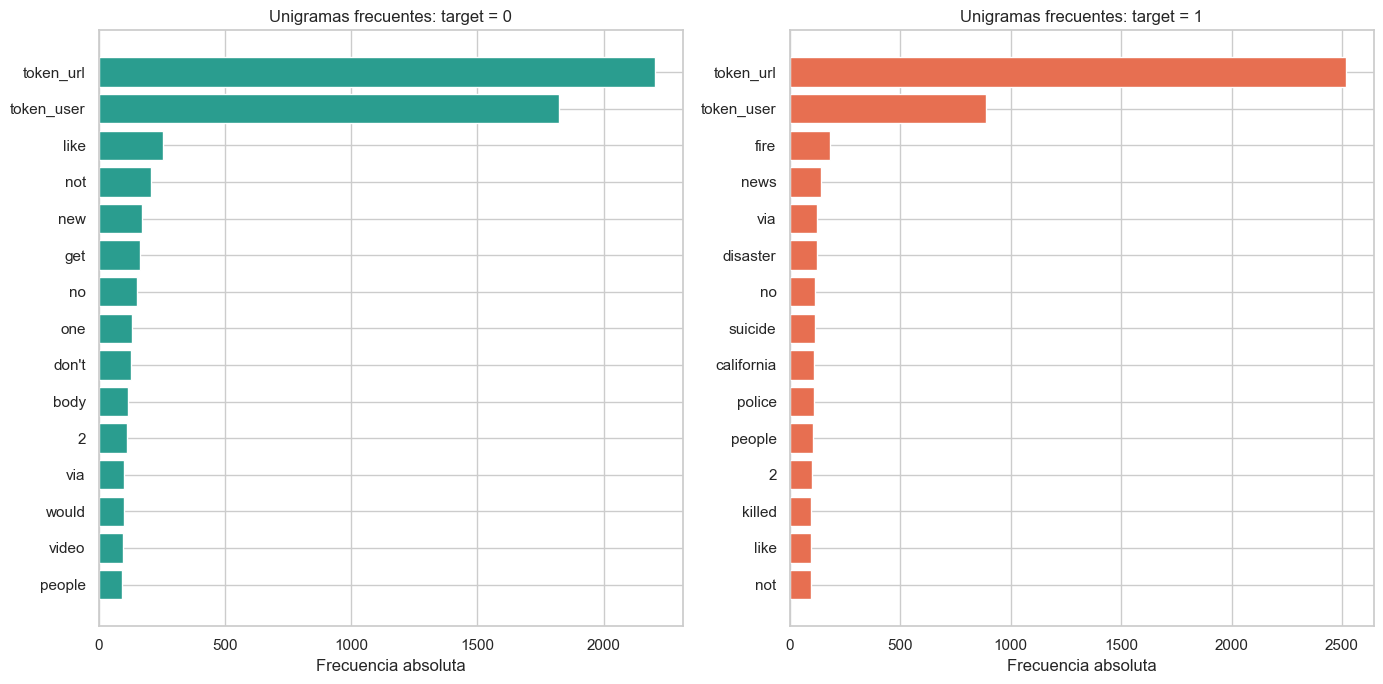

In [10]:
unigrams = top_by_class(df, n=1, top_n=20)
print("Unigramas más frecuentes en target = 0")
display(unigrams[0].style.format({"probability": "{:.4%}"}))
print("Unigramas más frecuentes en target = 1")
display(unigrams[1].style.format({"probability": "{:.4%}"}))

fig, axes = plt.subplots(1, 2, figsize=(14, 7), sharex=False)
for target, ax, color in [(0, axes[0], "#2a9d8f"), (1, axes[1], "#e76f51")]:
    plot_data = unigrams[target].head(15).sort_values("frequency")
    ax.barh(plot_data["ngram"], plot_data["frequency"], color=color)
    ax.set_title(f"Unigramas frecuentes: target = {target}")
    ax.set_xlabel("Frecuencia absoluta")
plt.tight_layout()
plt.show()

In [11]:
unigram_comparison = compare_classes(df, n=1, top_n=30)
display(unigram_comparison.style.format({
    "p_ngram_given_0": "{:.4%}",
    "p_ngram_given_1": "{:.4%}",
    "probability_difference": "{:+.4%}",
}))

shared_unigrams = unigram_comparison.query("frequency_0 > 0 and frequency_1 > 0").copy()
print("Términos frecuentes presentes en ambas categorías:")
display(shared_unigrams.sort_values("frequency_0", ascending=False).head(12))

,ngram,frequency_0,p_ngram_given_0,frequency_1,p_ngram_given_1,probability_difference
0,token_url,2204.000000,5.3446%,2519.000000,7.0996%,+1.7550%
1,fire,72.000000,0.1746%,182.000000,0.5130%,+0.3384%
2,suicide,7.000000,0.0170%,112.000000,0.3157%,+0.2987%
3,california,6.000000,0.0145%,111.000000,0.3128%,+0.2983%
4,killed,4.000000,0.0097%,95.000000,0.2677%,+0.2580%
5,hiroshima,1.000000,0.0024%,91.000000,0.2565%,+0.2541%
6,disaster,37.000000,0.0897%,121.000000,0.3410%,+0.2513%
7,news,59.000000,0.1431%,139.000000,0.3918%,+0.2487%
8,police,34.000000,0.0824%,109.000000,0.3072%,+0.2248%
9,families,7.000000,0.0170%,81.000000,0.2283%,+0.2113%


Términos frecuentes presentes en ambas categorías:


,ngram,frequency_0,p_ngram_given_0,frequency_1,p_ngram_given_1,probability_difference
0,token_url,2204.0,0.053446,2519.0,0.070996,0.017550
48,token_user,1823.0,0.044207,889.0,0.025056,-0.019151
47,like,254.0,0.006159,94.0,0.002649,-0.003510
44,not,205.0,0.004971,94.0,0.002649,-0.002322
46,new,171.0,0.004147,56.0,0.001578,-0.002568
43,get,163.0,0.003953,66.0,0.001860,-0.002093
27,no,151.0,0.003662,115.0,0.003241,-0.000420
36,one,131.0,0.003177,66.0,0.001860,-0.001317
40,don't,126.0,0.003055,47.0,0.001325,-0.001731
45,body,115.0,0.002789,14.0,0.000395,-0.002394


## 8. Bigramas

Los bigramas unen dos tokens contiguos y recuperan una pequeña parte del orden perdido por la bolsa de palabras. Esto permite distinguir expresiones completas y combinaciones con negación. Su costo es un vocabulario más grande y más disperso, por lo que su utilidad debe verificarse con los datos.

In [12]:
bigrams = top_by_class(df, n=2, top_n=20)
print("Bigramas más frecuentes en target = 0")
display(bigrams[0].style.format({"probability": "{:.4%}"}))
print("Bigramas más frecuentes en target = 1")
display(bigrams[1].style.format({"probability": "{:.4%}"}))

bigram_comparison = compare_classes(df, n=2, top_n=30)
display(bigram_comparison.style.format({
    "p_ngram_given_0": "{:.4%}",
    "p_ngram_given_1": "{:.4%}",
    "probability_difference": "{:+.4%}",
}))

Bigramas más frecuentes en target = 0


,ngram,frequency,probability
0,token_user token_user,369,1.0001%
1,token_url token_url,285,0.7724%
2,via token_user,85,0.2304%
3,token_url via,77,0.2087%
4,token_user token_url,75,0.2033%
5,cross body,39,0.1057%
6,liked token_user,34,0.0922%
7,token_user video,34,0.0922%
8,token_url token_user,32,0.0867%
9,video token_url,29,0.0786%


Bigramas más frecuentes en target = 1


,ngram,frequency,probability
0,token_url token_url,245,0.7606%
1,token_user token_user,186,0.5775%
2,via token_user,91,0.2825%
3,token_url via,88,0.2732%
4,suicide bomber,59,0.1832%
5,token_user token_url,46,0.1428%
6,northern california,41,0.1273%
7,oil spill,38,0.1180%
8,burning buildings,36,0.1118%
9,suicide bombing,35,0.1087%


,ngram,frequency_0,p_ngram_given_0,frequency_1,p_ngram_given_1,probability_difference
0,suicide bomber,0.000000,0.0000%,59.000000,0.1832%,+0.1832%
1,northern california,0.000000,0.0000%,41.000000,0.1273%,+0.1273%
2,oil spill,1.000000,0.0027%,38.000000,0.1180%,+0.1153%
3,suicide bombing,1.000000,0.0027%,35.000000,0.1087%,+0.1060%
4,california wildfire,0.000000,0.0000%,34.000000,0.1056%,+0.1056%
5,bomber detonated,0.000000,0.0000%,30.000000,0.0931%,+0.0931%
6,70 years,1.000000,0.0027%,30.000000,0.0931%,+0.0904%
7,confirmed mh370,0.000000,0.0000%,29.000000,0.0900%,+0.0900%
8,homes razed,0.000000,0.0000%,29.000000,0.0900%,+0.0900%
9,pkk suicide,0.000000,0.0000%,28.000000,0.0869%,+0.0869%


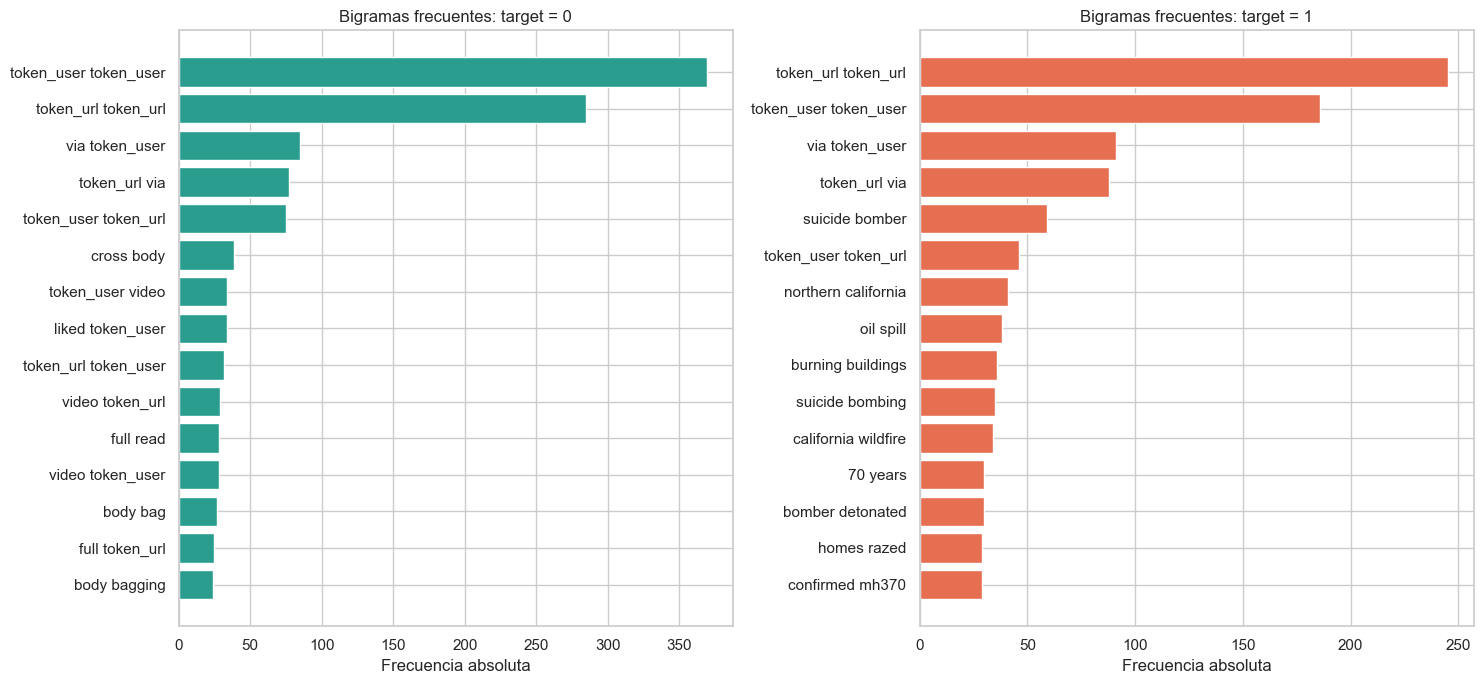

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
for target, ax, color in [(0, axes[0], "#2a9d8f"), (1, axes[1], "#e76f51")]:
    plot_data = bigrams[target].head(15).sort_values("frequency")
    ax.barh(plot_data["ngram"], plot_data["frequency"], color=color)
    ax.set_title(f"Bigramas frecuentes: target = {target}")
    ax.set_xlabel("Frecuencia absoluta")
plt.tight_layout()
plt.show()

## 9. Nubes de palabras

Las dos nubes se construyen con `text_processed` y los mismos parámetros de tamaño, cantidad de palabras y fondo. Para que el contenido semántico sea legible, solo en esta visualización se ocultan `token_url` y `token_user`; esos marcadores permanecen en el dataset, los n-gramas y el modelo. Las nubes son una vista exploratoria; las tablas anteriores son más adecuadas para comparar valores exactos.

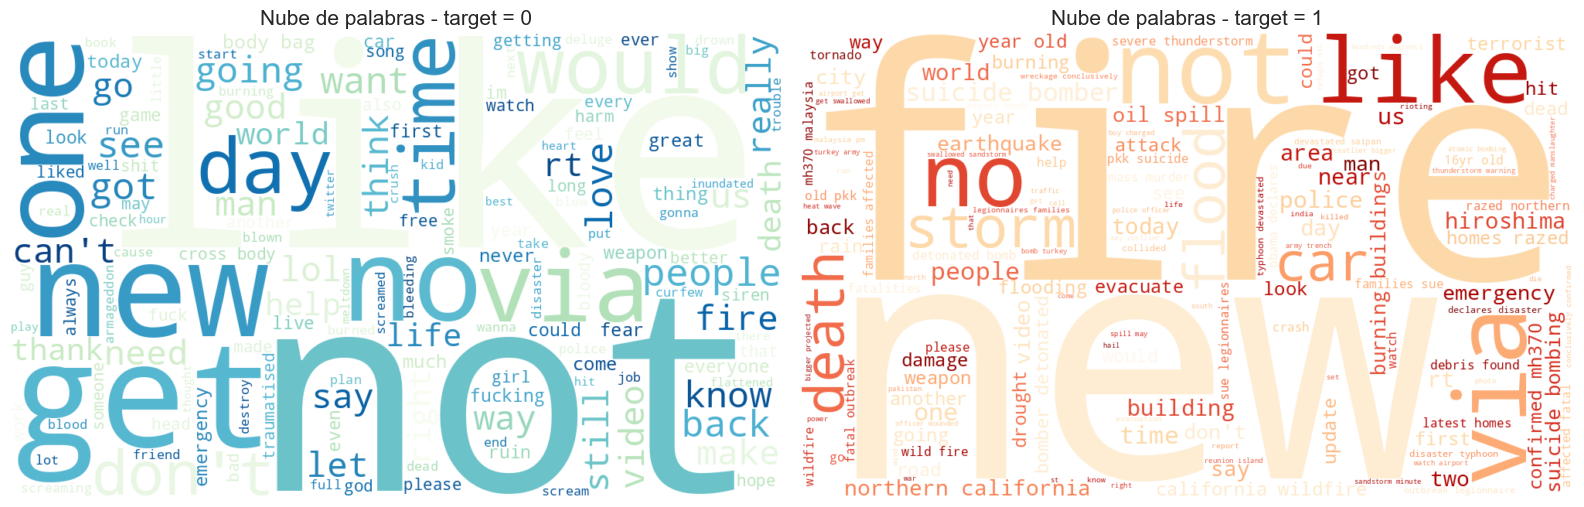

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for target, ax, colormap in [(0, axes[0], "GnBu"), (1, axes[1], "OrRd")]:
    corpus = " ".join(df.loc[df["target"] == target, "text_processed"])
    cloud = WordCloud(
        width=1000,
        height=600,
        background_color="white",
        max_words=150,
        random_state=SEED,
        colormap=colormap,
        stopwords={"token_url", "token_user"},
    ).generate(corpus)
    ax.imshow(cloud, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(f"Nube de palabras - target = {target}", fontsize=15)
plt.tight_layout()
plt.show()

## 10. Preparación para clasificación

Se utiliza una regresión logística como modelo preliminar. Es apropiada para matrices dispersas, ofrece una línea base sólida y permite interpretar el peso de cada término. No se usa Random Forest ni un transformer porque esta etapa busca una referencia académica simple y explicable.

## 11. División entrenamiento/prueba

La partición es 80/20, estratificada y reproducible (`random_state = 42`). El preprocesamiento anterior aplica reglas fijas y no aprende estadísticas del corpus. El vocabulario sí aprende de los datos, por lo que TF-IDF se ajusta **después** de dividir y únicamente con entrenamiento.

In [15]:
x_train, x_test, y_train, y_test = split_data(df, test_size=0.20)
split_distribution = pd.DataFrame({
    "train": y_train.value_counts().sort_index(),
    "test": y_test.value_counts().sort_index(),
})
split_distribution.loc["total"] = split_distribution.sum()
display(split_distribution)
print(f"Entrenamiento: {len(x_train):,} tweets | Prueba: {len(x_test):,} tweets")

,train,test
target,,
0,3473,869
1,2617,654
total,6090,1523


Entrenamiento: 6,090 tweets | Prueba: 1,523 tweets


## 12. Representación TF-IDF

TF-IDF pondera un término usando dos componentes:

- **TF (term frequency):** cuánto aparece el término dentro del documento.
- **IDF (inverse document frequency):** reduce el peso de términos presentes en muchos documentos y aumenta el de los menos comunes.

De forma simplificada, `tf-idf(t, d) = tf(t, d) × log(N / df(t))`. Frente a contar apariciones, ayuda a que una palabra repetida en casi todos los tweets no domine la representación. El vectorizador y el clasificador se encapsulan en un `Pipeline`: `fit` aprende vocabulario, IDF y coeficientes solo con `x_train`.

Se observan dos configuraciones preliminares: solo unigramas y unigramas + bigramas. No se realiza una búsqueda extensa de hiperparámetros ni se declara todavía un modelo final.

In [16]:
configurations = {
    "TF-IDF unigramas": (1, 1),
    "TF-IDF unigramas + bigramas": (1, 2),
}
models = {}
evaluations = {}

for name, ngram_range in configurations.items():
    pipeline = build_pipeline(ngram_range=ngram_range)
    pipeline.fit(x_train, y_train)
    models[name] = pipeline
    evaluations[name] = evaluate_model(pipeline, x_test, y_test)
    vocabulary_size = len(pipeline.named_steps["tfidf"].get_feature_names_out())
    print(f"{name}: {vocabulary_size:,} características")

TF-IDF unigramas: 5,427 características


TF-IDF unigramas + bigramas: 10,384 características


## 13. Modelo preliminar

La regresión logística estima la probabilidad de la clase positiva mediante una combinación lineal de las características TF-IDF. Se usa `max_iter = 1000` para asegurar convergencia y `random_state = 42` para reproducibilidad. Los demás parámetros permanecen cercanos a sus valores estándar, porque la selección formal corresponde a la segunda entrega.

In [17]:
metrics_table = pd.DataFrame({
    name: {metric: result[metric] for metric in ["accuracy", "precision", "recall", "f1"]}
    for name, result in evaluations.items()
}).T
display(metrics_table.style.format("{:.4f}"))

,accuracy,precision,recall,f1
TF-IDF unigramas,0.8227,0.8441,0.7202,0.7772
TF-IDF unigramas + bigramas,0.8188,0.8387,0.7156,0.7723


## 14. Evaluación

Accuracy resume todos los aciertos, pero no muestra si se están perdiendo desastres reales. Precision indica qué proporción de los tweets predichos como desastre realmente lo son; recall indica qué proporción de los desastres reales fue detectada. **F1** es la media armónica de precision y recall y resulta importante porque penaliza que una de las dos sea baja. La matriz de confusión hace visibles falsos positivos y falsos negativos.

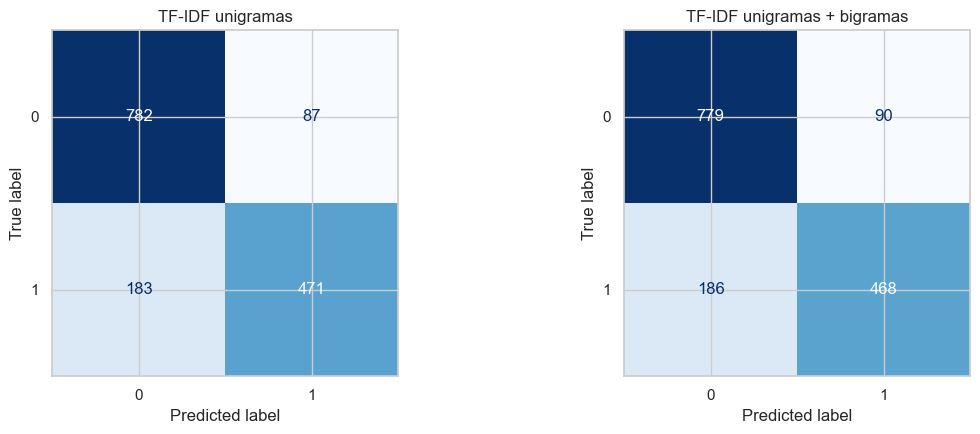

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, (name, result) in zip(axes, evaluations.items()):
    ConfusionMatrixDisplay(result["confusion_matrix"], display_labels=[0, 1]).plot(
        ax=ax, cmap="Blues", colorbar=False
    )
    ax.set_title(name)
plt.tight_layout()
plt.show()

## 15. Interpretación

En regresión logística, un coeficiente positivo alto empuja la predicción hacia `target = 1`; uno negativo empuja hacia `target = 0`. Para observar palabras y expresiones con contexto se inspecciona la configuración con unigramas + bigramas, sin presentarla todavía como ganadora definitiva.

In [19]:
interpretation_model = models["TF-IDF unigramas + bigramas"]
toward_0, toward_1 = coefficient_terms(interpretation_model, top_n=20)
print("Términos con mayor peso hacia target = 0")
display(toward_0)
print("Términos con mayor peso hacia target = 1")
display(toward_1)

Términos con mayor peso hacia target = 0


,term,coefficient
0,token_user,-2.157236
1,new,-2.073141
2,love,-1.919898
3,full,-1.560344
4,let,-1.518954
5,wrecked,-1.493845
6,bloody,-1.476343
7,ruin,-1.440693
8,harm,-1.414351
9,body,-1.402196


Términos con mayor peso hacia target = 1


,term,coefficient
0,hiroshima,3.220379
1,fires,2.631276
2,california,2.520802
3,token_url,2.392416
4,fire,2.347835
5,killed,2.332179
6,storm,2.161315
7,police,2.093357
8,train,2.090120
9,wildfire,2.056891


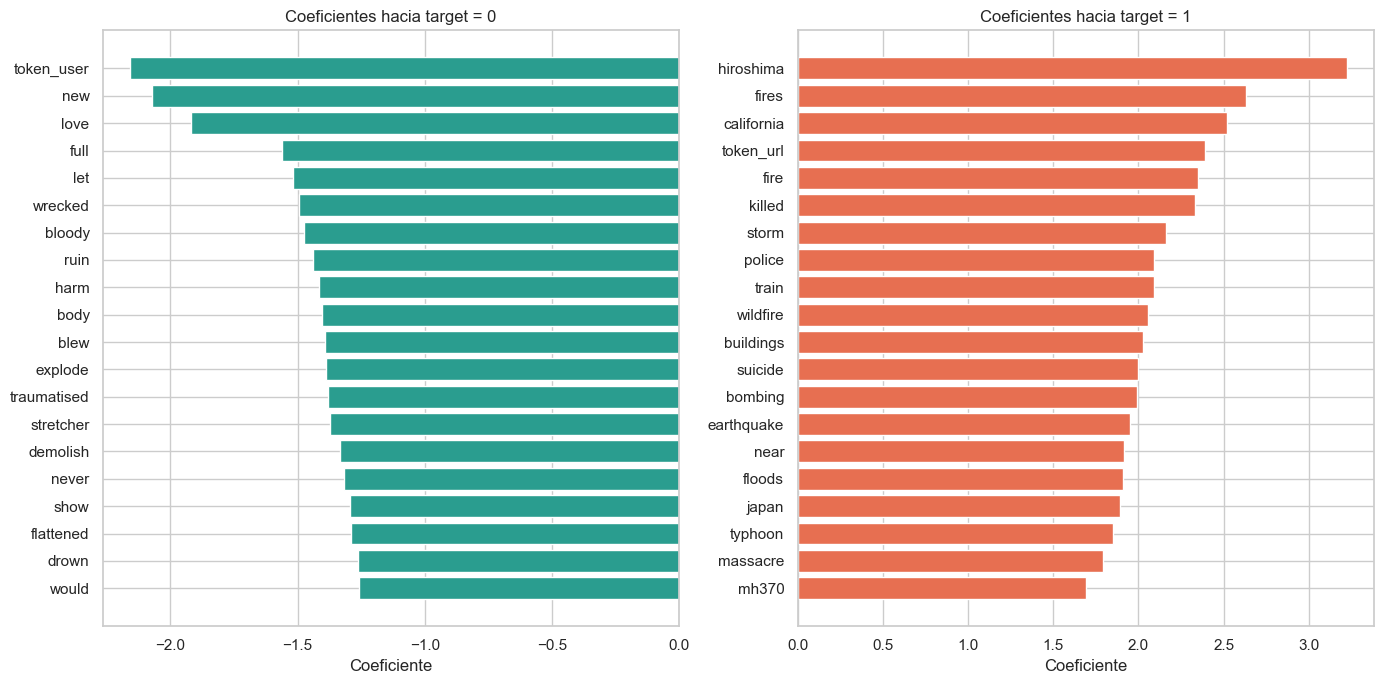

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes[0].barh(toward_0["term"], toward_0["coefficient"], color="#2a9d8f")
axes[0].invert_yaxis()
axes[0].set_title("Coeficientes hacia target = 0")
axes[0].set_xlabel("Coeficiente")
axes[1].barh(toward_1["term"], toward_1["coefficient"], color="#e76f51")
axes[1].invert_yaxis()
axes[1].set_title("Coeficientes hacia target = 1")
axes[1].set_xlabel("Coeficiente")
plt.tight_layout()
plt.show()

## 16. Conclusiones preliminares

La siguiente síntesis se genera con los resultados calculados en esta ejecución. Se limita a la primera entrega y no constituye la selección definitiva del modelo.

In [21]:
target_counts = summary["target_counts"]
top_u0 = ", ".join(unigrams[0].head(5)["ngram"])
top_u1 = ", ".join(unigrams[1].head(5)["ngram"])
top_b0 = ", ".join(bigrams[0].head(5)["ngram"])
top_b1 = ", ".join(bigrams[1].head(5)["ngram"])
metric_lines = "\n".join(
    f"- **{name}:** accuracy {result['accuracy']:.3f}, precision {result['precision']:.3f}, "
    f"recall {result['recall']:.3f} y F1 {result['f1']:.3f}."
    for name, result in evaluations.items()
)

display(Markdown(f"""
- El conjunto analizado contiene **{len(df):,} tweets**: **{target_counts.get(0, 0):,}** con `target = 0` y **{target_counts.get(1, 0):,}** con `target = 1`.
- Los unigramas más frecuentes de `target = 0` incluyen **{top_u0}**; en `target = 1` incluyen **{top_u1}**. Las frecuencias compartidas muestran que una palabra aislada no siempre basta para separar clases.
- Los bigramas frecuentes de `target = 0` incluyen **{top_b0}**; en `target = 1` incluyen **{top_b1}**. Estas expresiones agregan contexto, aunque también amplían el vocabulario.
{metric_lines}
- Los coeficientes permiten revisar si el modelo usa señales razonables o asociaciones accidentales.
"""))


- El conjunto analizado contiene **7,613 tweets**: **4,342** con `target = 0` y **3,271** con `target = 1`.
- Los unigramas más frecuentes de `target = 0` incluyen **token_url, token_user, like, not, new**; en `target = 1` incluyen **token_url, token_user, fire, news, disaster**. Las frecuencias compartidas muestran que una palabra aislada no siempre basta para separar clases.
- Los bigramas frecuentes de `target = 0` incluyen **token_user token_user, token_url token_url, via token_user, token_url via, token_user token_url**; en `target = 1` incluyen **token_url token_url, token_user token_user, via token_user, token_url via, suicide bomber**. Estas expresiones agregan contexto, aunque también amplían el vocabulario.
- **TF-IDF unigramas:** accuracy 0.823, precision 0.844, recall 0.720 y F1 0.777.
- **TF-IDF unigramas + bigramas:** accuracy 0.819, precision 0.839, recall 0.716 y F1 0.772.
- Los coeficientes permiten revisar si el modelo usa señales razonables o asociaciones accidentales.


# Segunda entrega

Las secciones siguientes completan el laboratorio. Se conserva el análisis preliminar como referencia y se agregan sentimiento, negatividad, comparación formal de modelos, selección final y clasificación de tweets nuevos.

## 17. Análisis de sentimientos

Se utiliza **VADER** porque es un método basado en léxico y reglas diseñado para textos breves de redes sociales en inglés. Produce proporciones negativa, neutral y positiva, además de un valor `compound` entre -1 y 1 que resume la intensidad.

El análisis se aplica al texto crudo, después de decodificar entidades HTML y retirar únicamente el símbolo `#` de los hashtags. No se usa `text_processed` porque VADER aprovecha mayúsculas, puntuación, emoticones, intensificadores y negaciones. Esto no cambia el preprocesamiento del clasificador: son dos representaciones con objetivos diferentes.

Las etiquetas usan los umbrales convencionales:

- `compound >= 0.05`: positivo.
- `compound <= -0.05`: negativo.
- Entre ambos valores: neutro.

VADER estima tono lingüístico, no la gravedad objetiva de un evento. Por eso un tweet sobre un desastre puede ser neutral si está redactado como un titular.

In [22]:
from src.sentiment import add_sentiment_features, analyze_sentiment
from src.model import (
    build_final_pipeline,
    classify_tweet,
    compare_candidates,
    compare_negativity_feature,
    split_frame_data,
)

df = add_sentiment_features(df, text_column="text")
save_processed_dataset(df, PROCESSED_PATH)

display(df[[
    "text", "target", "negativity", "neutrality",
    "positivity", "compound", "sentiment_label"
]].sample(10, random_state=SEED))
print(f"Dataset procesado actualizado: {PROCESSED_PATH.relative_to(ROOT)}")

,text,target,negativity,neutrality,positivity,compound,sentiment_label
2644,So you have a new weapon that can cause un-imaginable destruction.,1,0.424,0.576,0.000,-0.7096,negative
2227,The f$&amp;@ing things I do for #GISHWHES Just got soaked in a deluge going for pads and tampons. Thx @mishacollins @/@,0,0.000,0.878,0.122,0.3612,positive
5448,DT @georgegalloway: RT @Galloway4Mayor: ÛÏThe CoL police can catch a pickpocket in Liverpool Stree... http://t.co/v...,1,0.000,1.000,0.000,0.0000,neutral
132,Aftershock back to school kick off was great. I want to thank everyone for making it possible. What a great night.,0,0.000,0.556,0.444,0.9001,positive
6845,in response to trauma Children of Addicts develop a defensive self - one that decreases vulnerability. (3,0,0.264,0.674,0.062,-0.5574,negative
5559,@Calum5SOS you look like you got caught in a rainstorm this is amazing and disgusting at the same time,0,0.138,0.607,0.255,0.4404,positive
1765,my favorite lady came to our volunteer meeting\nhopefully joining her youth collision and i am excite http://t.co/Ij...,1,0.103,0.535,0.362,0.7430,positive
1817,@brianroemmele UX fail of EMV - people want to insert and remove quickly like a gas pump stripe reader. 1 person tol...,1,0.124,0.742,0.134,-0.1779,negative
6810,Can't find my ariana grande shirt this is a fucking tragedy,0,0.343,0.657,0.000,-0.6901,negative
4398,The Murderous Story Of AmericaÛªs First Hijacking http://t.co/EYUGk6byxr,1,0.375,0.625,0.000,-0.6369,negative


Dataset procesado actualizado: data\processed\train_processed.csv


### 17.1 Revisión de emojis y emoticones

Conservar estas señales sigue siendo apropiado para tweets, pero primero se revisa cómo llegaron en el archivo. Se cuentan emoticones ASCII después de retirar URLs para no confundir `://` con una cara. También se buscan tokens de emoji reconocidos por el preprocesamiento y una secuencia de mojibake, que evidencia caracteres dañados por una codificación anterior.

Los símbolos dañados se conservan en `text` como evidencia, pero no se intenta reconstruirlos: adivinar el emoji original podría inventar sentimiento. VADER todavía aprovecha emoticones ASCII, puntuación y lenguaje; la corrupción de parte de los símbolos se reconoce como una limitación.

In [23]:
text_without_urls = df["text"].str.replace(
    r"https?://\S+|www\.\S+", " ", regex=True
)
emoji_review = pd.Series({
    "tweets_with_recognized_unicode_emoji": int(
        df["text_processed"].str.contains("emoji_u", regex=False).sum()
    ),
    "tweets_with_classic_ascii_emoticon": int(
        text_without_urls.str.contains(
            r"(?<!\w)[:;=]-?[)(DPp/](?!\w)", regex=True, na=False
        ).sum()
    ),
    "tweets_with_xd_or_heart": int(
        text_without_urls.str.contains(
            r"(?<!\w)(?:xD|XD|<3)(?!\w)", regex=True, na=False
        ).sum()
    ),
    "tweets_with_suspected_mojibake": int(
        df["text"].str.contains("\u0089Û", regex=False, na=False).sum()
    ),
}).rename("tweets")
display(emoji_review.to_frame())

,tweets
tweets_with_recognized_unicode_emoji,0
tweets_with_classic_ascii_emoticon,64
tweets_with_xd_or_heart,5
tweets_with_suspected_mojibake,612


## 18. Distribución de sentimiento

La tabla muestra cantidades y porcentajes dentro de cada categoría de desastre. Esto permite separar dos preguntas: cuál es el sentimiento predominante en todo el corpus y si cambia entre `target = 0` y `target = 1`.

Cantidad de tweets por sentimiento y target


sentiment_label,negative,neutral,positive
target,,,
0,1849,1097,1396
1,1880,855,536


Porcentaje dentro de cada target


sentiment_label,negative,neutral,positive
target,,,
0,42.58%,25.26%,32.15%
1,57.47%,26.14%,16.39%


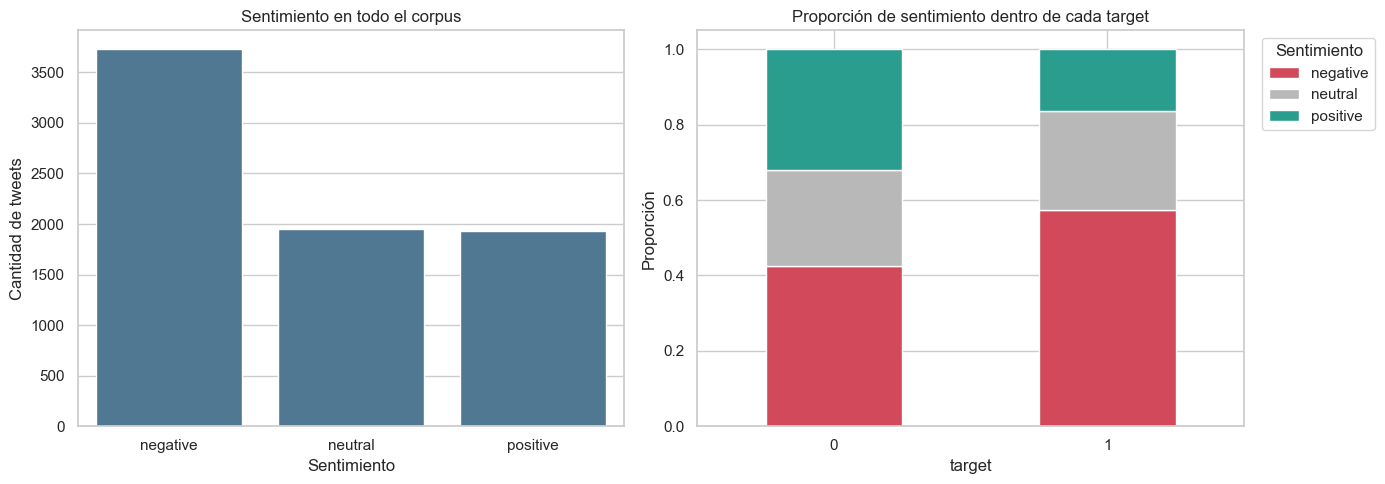

In [24]:
sentiment_counts = pd.crosstab(df["target"], df["sentiment_label"])
sentiment_percentages = pd.crosstab(
    df["target"], df["sentiment_label"], normalize="index"
)

print("Cantidad de tweets por sentimiento y target")
display(sentiment_counts)
print("Porcentaje dentro de cada target")
display(sentiment_percentages.style.format("{:.2%}"))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(
    data=df,
    x="sentiment_label",
    order=["negative", "neutral", "positive"],
    color="#457b9d",
    ax=axes[0],
)
axes[0].set(
    title="Sentimiento en todo el corpus",
    xlabel="Sentimiento",
    ylabel="Cantidad de tweets",
)

sentiment_percentages[["negative", "neutral", "positive"]].plot(
    kind="bar",
    stacked=True,
    color=["#d1495b", "#b8b8b8", "#2a9d8f"],
    ax=axes[1],
)
axes[1].set(
    title="Proporción de sentimiento dentro de cada target",
    xlabel="target",
    ylabel="Proporción",
)
axes[1].legend(title="Sentimiento", bbox_to_anchor=(1.02, 1))
axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

## 19. Tweets con sentimiento más negativo y positivo

El ranking se basa en `compound`. Los resultados son una salida del léxico, no una anotación humana; sarcasmo, nombres propios y lenguaje figurado pueden producir casos discutibles.

In [25]:
ranking_columns = [
    "id", "text", "target", "negativity", "positivity",
    "compound", "sentiment_label",
]
top_negative = df.nsmallest(10, "compound")[ranking_columns]
top_positive = df.nlargest(10, "compound")[ranking_columns]

print("10 tweets con compound más negativo")
display(top_negative)
print("10 tweets con compound más positivo")
display(top_positive)

10 tweets con compound más negativo


,id,text,target,negativity,positivity,compound,sentiment_label
7472,10689,wreck? wreck wreck wreck wreck wreck wreck wreck wreck wreck wreck wreck wreck?,0,1.000,0.000,-0.9883,negative
6414,9172,@Abu_Baraa1 Suicide bomber targets Saudi mosque at least 13 dead - Suicide bomber targets Saudi mosque at least 13 d...,1,0.542,0.000,-0.9686,negative
6411,9166,Suicide bomber kills 15 in Saudi security site mosque - A suicide bomber killed at least 15 people in an attack on.....,1,0.536,0.064,-0.9623,negative
6393,9137,? 19th Day Since 17-Jul-2015 -- Nigeria: Suicide Bomb Attacks Killed 64 People; Blamed: Boko Haram [L.A. Times/AP] |...,1,0.583,0.000,-0.9595,negative
6407,9159,17 killed in SÛªArabia mosque suicide bombing\n\nA suicide bomber attacked a mosque in Aseer south-western Saudi......,1,0.579,0.000,-0.9552,negative
2932,4213,at the lake \n*sees a dead fish*\nme: poor little guy i wonder what happened\nashley: idk maybe it drowned\n wtf ??...,0,0.538,0.000,-0.9549,negative
472,682,illegal alien released by Obama/DHS 4 times Charged With Rape &amp; Murder of Santa Maria CA Woman Had Prior Offense...,1,0.553,0.000,-0.9538,negative
1540,2225,Bomb Crash Loot Riot Emergency Pipe Bomb Nuclear Chemical Spill Gas Ricin Leak Violence Drugs Cartel Cocaine Marijua...,1,0.566,0.096,-0.9524,negative
6818,9765,Bomb head? Explosive decisions dat produced more dead children than dead bodies trapped tween buildings on that day ...,1,0.481,0.000,-0.9500,negative
6930,9940,@cspan #Prez. Mr. President you are the biggest terrorist and trouble maker in the world. You create terrorist you s...,1,0.481,0.060,-0.9493,negative


10 tweets con compound más positivo


,id,text,target,negativity,positivity,compound,sentiment_label
6992,10028,Check out 'Want Twister Tickets AND A VIP EXPERIENCE To See SHANIA? CLICK HERE:' at http://t.co/3GEROQ49o1\nI would...,0,0.000,0.598,0.9730,positive
6534,9345,@thoutaylorbrown I feel like accidents are just drawn to you but I'm happy you've survived all of them. Hope you're ...,0,0.049,0.539,0.9564,positive
6292,8989,TodayÛªs storm will pass; let tomorrowÛªs light greet you with a kiss. Bask in this loving warmth; let your soul r...,1,0.000,0.491,0.9471,positive
3163,4541,@batfanuk we enjoyed the show today. Great fun. The emergency non evacuation was interesting. Have a great run.,0,0.084,0.563,0.9423,positive
3382,4844,@batfanuk we enjoyed the show today. Great fun. The emergency non evacuation was interesting. Have a great run.,0,0.084,0.563,0.9423,positive
6778,9710,Maaaaan I love Love Without Tragedy by @rihanna I wish she made the whole song,0,0.000,0.619,0.9394,positive
6295,8994,Free Ebay Sniping RT? http://t.co/B231Ul1O1K Lumbar Extender Back Stretcher Excellent Condition!! ?Please Favorite &...,0,0.000,0.632,0.9376,positive
2457,3525,@Raishimi33 :) well I think that sounds like a fine plan where little derailment is possible so I applaud you :),1,0.000,0.575,0.9356,positive
1001,1453,I'm not a Drake fan but I enjoy seeing him body-bagging people. Great marketing lol.,0,0.061,0.566,0.9345,positive
6560,9386,@duchovbutt @Starbuck_Scully @MadMakNY @davidduchovny yeah we survived 9 seasons and 2 movies. Let's hope for the go...,0,0.000,0.538,0.9344,positive


## 20. ¿Los tweets sobre desastres reales son más negativos?

Se comparan la media y mediana de `negativity` y `compound`, además de la proporción clasificada como negativa. La caja permite observar la distribución completa y evita basar la respuesta únicamente en un promedio.

,tweets,negativity_mean,negativity_median,compound_mean,compound_median,negative_tweet_rate
target,,,,,,
0,4342,0.1337,0.0920,-0.0560,0.0000,42.58%
1,3271,0.1765,0.1590,-0.2669,-0.3182,57.47%


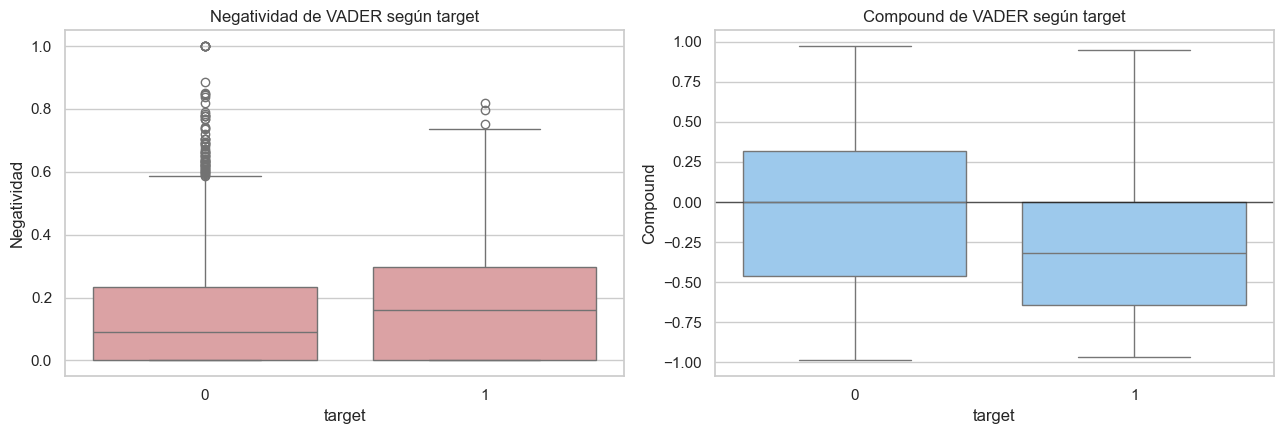

In [26]:
sentiment_by_target = df.groupby("target").agg(
    tweets=("id", "count"),
    negativity_mean=("negativity", "mean"),
    negativity_median=("negativity", "median"),
    compound_mean=("compound", "mean"),
    compound_median=("compound", "median"),
)
negative_rate = (
    df["sentiment_label"].eq("negative")
    .groupby(df["target"])
    .mean()
    .rename("negative_tweet_rate")
)
sentiment_by_target = sentiment_by_target.join(negative_rate)
display(sentiment_by_target.style.format({
    "negativity_mean": "{:.4f}",
    "negativity_median": "{:.4f}",
    "compound_mean": "{:.4f}",
    "compound_median": "{:.4f}",
    "negative_tweet_rate": "{:.2%}",
}))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.boxplot(data=df, x="target", y="negativity", color="#e5989b", ax=axes[0])
axes[0].set(
    title="Negatividad de VADER según target",
    xlabel="target",
    ylabel="Negatividad",
)
sns.boxplot(data=df, x="target", y="compound", color="#90caf9", ax=axes[1])
axes[1].axhline(0, color="black", linewidth=1, alpha=0.6)
axes[1].set(
    title="Compound de VADER según target",
    xlabel="target",
    ylabel="Compound",
)
plt.tight_layout()
plt.show()

In [27]:
neg_0 = sentiment_by_target.loc[0, "negativity_mean"]
neg_1 = sentiment_by_target.loc[1, "negativity_mean"]
rate_0 = sentiment_by_target.loc[0, "negative_tweet_rate"]
rate_1 = sentiment_by_target.loc[1, "negative_tweet_rate"]
direction = "mayor" if neg_1 > neg_0 else "menor"

display(Markdown(f'''
En estos datos, la negatividad media de `target = 1` es **{neg_1:.4f}** y la de
`target = 0` es **{neg_0:.4f}**. Por lo tanto, la negatividad media de los tweets
sobre desastres reales es **{direction}**. VADER etiqueta como negativos
**{rate_1:.2%}** de los tweets de desastre real y **{rate_0:.2%}** de los demás.
La diferencia describe este corpus y no implica que VADER comprenda la gravedad
del evento.
'''))


En estos datos, la negatividad media de `target = 1` es **0.1765** y la de
`target = 0` es **0.1337**. Por lo tanto, la negatividad media de los tweets
sobre desastres reales es **mayor**. VADER etiqueta como negativos
**57.47%** de los tweets de desastre real y **42.58%** de los demás.
La diferencia describe este corpus y no implica que VADER comprenda la gravedad
del evento.


## 21. Variable de negatividad

La columna `negativity` corresponde a la proporción negativa estimada por VADER y toma valores entre 0 y 1. Se incorpora como una característica numérica adicional a TF-IDF. Como VADER usa un léxico fijo y no aprende del dataset, calcularla antes de la partición no transmite etiquetas ni vocabulario del conjunto de prueba.

In [28]:
display(df[["id", "text", "target", "negativity"]].head())
display(df["negativity"].describe().to_frame().T)

,id,text,target,negativity
0,1,Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all,1,0.000
1,4,Forest fire near La Ronge Sask. Canada,1,0.286
2,5,All residents asked to 'shelter in place' are being notified by officers. No other evacuation or shelter in place or...,1,0.095
3,6,"13,000 people receive #wildfires evacuation orders in California",1,0.000
4,7,Just got sent this photo from Ruby #Alaska as smoke from #wildfires pours into a school,1,0.000


,count,mean,std,min,25%,50%,75%,max
negativity,7613.0,0.152076,0.165109,0.0,0.0,0.128,0.262,1.0


## 22. Comparación y selección de modelos

Se comparan regresión logística, Naive Bayes multinomial y SVM lineal. Cada algoritmo se prueba con unigramas y con unigramas + bigramas.

Para evitar fuga de información:

1. Se conserva la partición estratificada 80/20.
2. Las seis alternativas se comparan con validación cruzada estratificada de cinco particiones **solo dentro del entrenamiento**.
3. F1 promedio es el criterio principal; accuracy se utiliza únicamente como desempate.
4. El conjunto de prueba se consulta después de elegir la configuración.

Cada fold ajusta su propio TF-IDF. De este modo, el vocabulario de validación tampoco entra al entrenamiento del fold.

,classifier,representation,ngram_range,cv_accuracy_mean,cv_precision_mean,cv_recall_mean,cv_f1_mean,cv_f1_std
0,LogisticRegression,unigrams,"(1, 1)",0.7980,0.8224,0.6763,0.7421,0.0135
1,LogisticRegression,unigrams+bigrams,"(1, 2)",0.7970,0.8269,0.6679,0.7387,0.0160
2,LinearSVC,unigrams,"(1, 1)",0.7829,0.7672,0.7111,0.7379,0.0156
3,MultinomialNB,unigrams,"(1, 1)",0.7938,0.8264,0.6595,0.7333,0.0109
4,LinearSVC,unigrams+bigrams,"(1, 2)",0.7791,0.7640,0.7035,0.7324,0.0182
5,MultinomialNB,unigrams+bigrams,"(1, 2)",0.7918,0.8569,0.6194,0.7186,0.0167


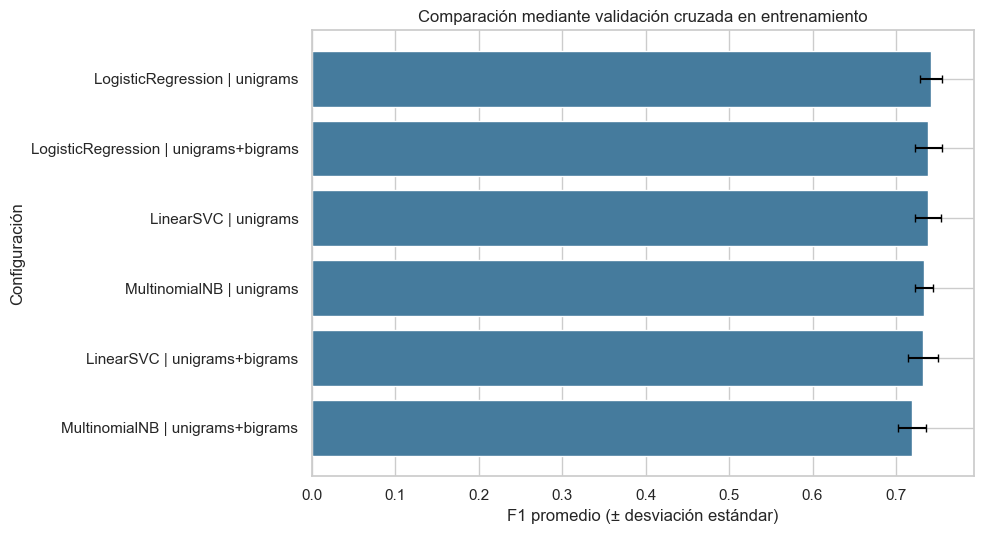

In [29]:
x_train_final, x_test_final, y_train_final, y_test_final = split_frame_data(
    df, test_size=0.20
)
candidate_results = compare_candidates(x_train_final, y_train_final, folds=5)
display(candidate_results.style.format({
    "cv_accuracy_mean": "{:.4f}",
    "cv_precision_mean": "{:.4f}",
    "cv_recall_mean": "{:.4f}",
    "cv_f1_mean": "{:.4f}",
    "cv_f1_std": "{:.4f}",
}))

fig, ax = plt.subplots(figsize=(10, 5.5))
candidate_plot = candidate_results.sort_values("cv_f1_mean")
labels = (
    candidate_plot["classifier"] + " | " + candidate_plot["representation"]
)
ax.barh(labels, candidate_plot["cv_f1_mean"], color="#457b9d")
ax.errorbar(
    candidate_plot["cv_f1_mean"],
    range(len(candidate_plot)),
    xerr=candidate_plot["cv_f1_std"],
    fmt="none",
    color="black",
    capsize=3,
)
ax.set(
    title="Comparación mediante validación cruzada en entrenamiento",
    xlabel="F1 promedio (± desviación estándar)",
    ylabel="Configuración",
)
plt.tight_layout()
plt.show()

In [30]:
best_candidate = candidate_results.iloc[0]
selected_classifier = best_candidate["classifier"]
selected_representation = best_candidate["representation"]
selected_ngram_range = tuple(best_candidate["ngram_range"])

display(Markdown(f'''
La configuración seleccionada antes de observar prueba es
**{selected_classifier} con {selected_representation}**. Obtuvo un F1 promedio
de **{best_candidate['cv_f1_mean']:.4f} ± {best_candidate['cv_f1_std']:.4f}**
en las cinco particiones de entrenamiento.
'''))


La configuración seleccionada antes de observar prueba es
**LogisticRegression con unigrams**. Obtuvo un F1 promedio
de **0.7421 ± 0.0135**
en las cinco particiones de entrenamiento.


## 23. ¿La negatividad mejora el modelo?

Se mantiene el algoritmo y la representación seleccionados, y se comparan dos variantes mediante los mismos folds de entrenamiento: TF-IDF solo y TF-IDF + `negativity`. La decisión de incluir la variable se toma con F1 de validación cruzada, no con el resultado de prueba.

In [31]:
negativity_comparison = compare_negativity_feature(
    selected_classifier,
    selected_ngram_range,
    x_train_final,
    y_train_final,
    folds=5,
)
display(negativity_comparison.style.format({
    "cv_accuracy_mean": "{:.4f}",
    "cv_precision_mean": "{:.4f}",
    "cv_recall_mean": "{:.4f}",
    "cv_f1_mean": "{:.4f}",
    "cv_f1_std": "{:.4f}",
}))

base_cv_f1 = negativity_comparison.loc[
    ~negativity_comparison["include_negativity"], "cv_f1_mean"
].iloc[0]
negative_cv_f1 = negativity_comparison.loc[
    negativity_comparison["include_negativity"], "cv_f1_mean"
].iloc[0]
negativity_delta = negative_cv_f1 - base_cv_f1
use_negativity_final = bool(negative_cv_f1 > base_cv_f1)

decision_text = "se conserva" if use_negativity_final else "no se conserva"
display(Markdown(f'''
Agregar `negativity` cambió el F1 promedio de **{base_cv_f1:.4f}** a
**{negative_cv_f1:.4f}** (diferencia **{negativity_delta:+.4f}**). Según el
criterio definido, la variable **{decision_text}** en el modelo final.
'''))

,include_negativity,cv_accuracy_mean,cv_precision_mean,cv_recall_mean,cv_f1_mean,cv_f1_std
0,False,0.7980,0.8224,0.6763,0.7421,0.0135
1,True,0.7947,0.8173,0.6729,0.7380,0.0133



Agregar `negativity` cambió el F1 promedio de **0.7421** a
**0.7380** (diferencia **-0.0041**). Según el
criterio definido, la variable **no se conserva** en el modelo final.


## 24. Evaluación final sobre prueba

Después de cerrar la selección, se ajustan las variantes sin y con negatividad usando todo el entrenamiento. Ambas se reportan para responder la pregunta del laboratorio; el modelo final sigue siendo el decidido mediante validación cruzada.

,accuracy,precision,recall,f1
TF-IDF,0.8227,0.8441,0.7202,0.7772
TF-IDF + negatividad,0.8188,0.8387,0.7156,0.7723


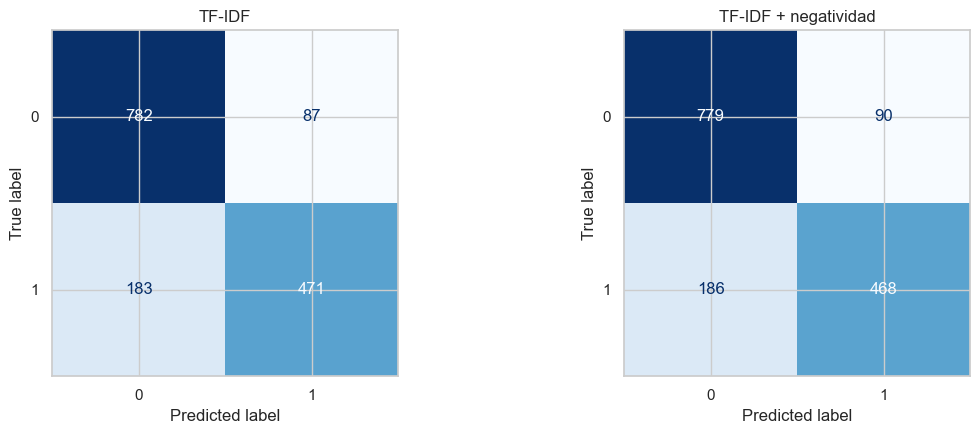

In [32]:
final_variants = {}
final_test_results = {}
for include_negativity in (False, True):
    variant = build_final_pipeline(
        selected_classifier,
        ngram_range=selected_ngram_range,
        include_negativity=include_negativity,
    )
    variant.fit(x_train_final, y_train_final)
    final_variants[include_negativity] = variant
    final_test_results[include_negativity] = evaluate_model(
        variant, x_test_final, y_test_final
    )

test_metrics = pd.DataFrame({
    ("TF-IDF + negatividad" if include else "TF-IDF"): {
        metric: result[metric]
        for metric in ["accuracy", "precision", "recall", "f1"]
    }
    for include, result in final_test_results.items()
}).T
display(test_metrics.style.format("{:.4f}"))

final_model = final_variants[use_negativity_final]
final_evaluation = final_test_results[use_negativity_final]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, include in zip(axes, (False, True)):
    title = "TF-IDF + negatividad" if include else "TF-IDF"
    ConfusionMatrixDisplay(
        final_test_results[include]["confusion_matrix"],
        display_labels=[0, 1],
    ).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(title)
plt.tight_layout()
plt.show()

## 25. Función final de clasificación

La función recibe un tweet sin preprocesar. Internamente aplica las mismas reglas de limpieza, calcula negatividad y usa el pipeline entrenado. Devuelve la clase de desastre y una probabilidad cuando el algoritmo la ofrece; para SVM lineal devuelve la distancia al hiperplano.

In [33]:
def clasificar_tweet(tweet):
    return classify_tweet(final_model, tweet)


example_tweets = [
    "A wildfire is spreading near the town and residents are being evacuated.",
    "My homework is a complete disaster lol.",
    "No injuries were reported after the small fire.",
]
display(pd.DataFrame([clasificar_tweet(tweet) for tweet in example_tweets]))

,tweet,prediction,classification,negativity,sentiment,probability_disaster
0,A wildfire is spreading near the town and residents are being evacuated.,1,real disaster,0.000,neutral,0.910619
1,My homework is a complete disaster lol.,0,not a real disaster,0.376,negative,0.280849
2,No injuries were reported after the small fire.,1,real disaster,0.434,negative,0.580950


## 26. Conclusiones finales

Las conclusiones siguientes se generan con los valores obtenidos en esta ejecución.

In [34]:
test_name = "TF-IDF + negatividad" if use_negativity_final else "TF-IDF"
mean_compound_0 = sentiment_by_target.loc[0, "compound_mean"]
mean_compound_1 = sentiment_by_target.loc[1, "compound_mean"]

display(Markdown(f'''
- El corpus etiquetado contiene **{len(df):,} tweets** y mantiene un desbalance moderado: 57% pertenece a `target = 0` y 43% a `target = 1`.
- Los n-gramas mostraron que expresiones como `suicide bomber`, `oil spill` y `burning buildings` aportan contexto que una palabra aislada no conserva.
- VADER encontró una negatividad media de **{neg_0:.4f}** en `target = 0` y **{neg_1:.4f}** en `target = 1`. El compound promedio fue **{mean_compound_0:.4f}** y **{mean_compound_1:.4f}**, respectivamente.
- La comparación interna seleccionó **{selected_classifier} con {selected_representation}**, con F1 de validación cruzada **{best_candidate['cv_f1_mean']:.4f}**.
- La variable de negatividad cambió el F1 de validación en **{negativity_delta:+.4f}**. Por ese resultado, **{decision_text}** en la configuración final.
- El modelo final **{test_name}** obtuvo en prueba: accuracy **{final_evaluation['accuracy']:.4f}**, precision **{final_evaluation['precision']:.4f}**, recall **{final_evaluation['recall']:.4f}** y F1 **{final_evaluation['f1']:.4f}**.
- El modelo es una línea base reproducible e interpretable. Sus límites incluyen lenguaje figurado, sarcasmo, ambigüedad y asociaciones dependientes de este corpus.
'''))


- El corpus etiquetado contiene **7,613 tweets** y mantiene un desbalance moderado: 57% pertenece a `target = 0` y 43% a `target = 1`.
- Los n-gramas mostraron que expresiones como `suicide bomber`, `oil spill` y `burning buildings` aportan contexto que una palabra aislada no conserva.
- VADER encontró una negatividad media de **0.1337** en `target = 0` y **0.1765** en `target = 1`. El compound promedio fue **-0.0560** y **-0.2669**, respectivamente.
- La comparación interna seleccionó **LogisticRegression con unigrams**, con F1 de validación cruzada **0.7421**.
- La variable de negatividad cambió el F1 de validación en **-0.0041**. Por ese resultado, **no se conserva** en la configuración final.
- El modelo final **TF-IDF** obtuvo en prueba: accuracy **0.8227**, precision **0.8441**, recall **0.7202** y F1 **0.7772**.
- El modelo es una línea base reproducible e interpretable. Sus límites incluyen lenguaje figurado, sarcasmo, ambigüedad y asociaciones dependientes de este corpus.


## 27. Referencias adicionales

- Hutto, C. J., & Gilbert, E. (2014). *VADER: A Parsimonious Rule-Based Model for Sentiment Analysis of Social Media Text*. Proceedings of the International AAAI Conference on Web and Social Media, 8(1), 216–225. https://doi.org/10.1609/icwsm.v8i1.14550
- NLTK. `SentimentIntensityAnalyzer` documentation: https://www.nltk.org/api/nltk.sentiment.SentimentIntensityAnalyzer.html
- scikit-learn. Model selection and evaluation documentation: https://scikit-learn.org/stable/model_selection.html